# Demo & Edge Case Testing
In this notebook, we will load both the trained Computer Vision (ResNet-18) and NLP (BERT) models.
We will test them against edge cases to demonstrate their robustness.

* **NLP Edge Cases:** Typos, excessive punctuation, mixed casing, and multiple entities.
* **CV Edge Cases:** Testing images with noise, unusual angles, or lower confidence thresholds using direct web URLs.

In [27]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt

## 1. NLP Model (BERT) Testing
Loading the fine-tuned BERT model from the local directory.

In [28]:
nlp_model_path = "ner_classification/model"

try:
    ner_pipeline = pipeline(
        "ner",
        model=nlp_model_path,
        tokenizer=nlp_model_path,
        aggregation_strategy="simple"
    )
    print("NER Model loaded successfully!")
except Exception as e:
    print(f"Error loading NER model: {e}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

NER Model loaded successfully!


### 1.1 Testing NLP Edge Cases
Let's see how the model handles difficult inputs:
1. **Typos:** "elephaaant", "doog" (BERT's subword tokenizer helps here)
2. **Noise:** "!!!wOLf,,, is hEre"
3. **Multiple entities:** Two or more animals in one sentence.
4. **No animals:** A sentence with objects but no animals.

In [29]:
edge_case_texts = [
    "I saw a huge elephaaant in the zoo today.",
    "Look at that cutteee dogs!",
    "!!!wOLf,,, is hEre hiding behind the tree...",
    "The cat was chasing a small mouse while the dog watched.",
    "I bought a new computer and a wooden table yesterday."
]

for text in edge_case_texts:
    print(f"Input: '{text}'")
    results = ner_pipeline(text)
    animals = [res['word'] for res in results if res['entity_group'] == 'ANIMAL']

    if animals:
        print(f"Found animals: {animals}\n")
    else:
        print("No animals found.\n")

Input: 'I saw a huge elephaaant in the zoo today.'
Found animals: ['el']

Input: 'Look at that cutteee dogs!'
Found animals: ['dogs']

Input: '!!!wOLf,,, is hEre hiding behind the tree...'
Found animals: ['wolf']

Input: 'The cat was chasing a small mouse while the dog watched.'
Found animals: ['cat', 'mouse', 'dog']

Input: 'I bought a new computer and a wooden table yesterday.'
No animals found.



## 2. Computer Vision Model (ResNet-18) Testing
Loading the custom trained ResNet-18 model.

In [30]:
cv_model_path = "image_classification/model/im_cl_model.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_cv_model(path):
    """
    Initializes ResNet-18, modifies the final layer based on saved class names,
    and loads the trained weights.
    """
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    class_names = checkpoint['class_names']

    model = models.resnet18()
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, len(class_names))
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()

    return model, class_names

try:
    cv_model, cv_classes = load_cv_model(cv_model_path)
    print(f"CV Model loaded successfully! Classes: {cv_classes}")
except Exception as e:
    print(f"Error loading CV model. Ensure you have trained it first. Error: {e}")

CV Model loaded successfully! Classes: ['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison', 'boar', 'butterfly', 'cat', 'caterpillar', 'chimpanzee', 'cockroach', 'cow', 'coyote', 'crab', 'crow', 'deer', 'dog', 'dolphin', 'donkey', 'dragonfly', 'duck', 'eagle', 'elephant', 'flamingo', 'fly', 'fox', 'goat', 'goldfish', 'goose', 'gorilla', 'grasshopper', 'hamster', 'hare', 'hedgehog', 'hippopotamus', 'hornbill', 'horse', 'hummingbird', 'hyena', 'jellyfish', 'kangaroo', 'koala', 'ladybugs', 'leopard', 'lion', 'lizard', 'lobster', 'mosquito', 'moth', 'mouse', 'octopus', 'okapi', 'orangutan', 'otter', 'owl', 'ox', 'oyster', 'panda', 'parrot', 'pelecaniformes', 'penguin', 'pig', 'pigeon', 'porcupine', 'possum', 'raccoon', 'rat', 'reindeer', 'rhinoceros', 'sandpiper', 'seahorse', 'seal', 'shark', 'sheep', 'snake', 'sparrow', 'squid', 'squirrel', 'starfish', 'swan', 'tiger', 'turkey', 'turtle', 'whale', 'wolf', 'wombat', 'woodpecker', 'zebra']


### 2.1 Testing CV Edge Cases (via URL)
We will define a helper function to fetch images directly from the web.
This allows us to test edge cases (e.g., heavily edited photos, cartoons, or obscured animals) without downloading them locally.

Testing Normal Image:


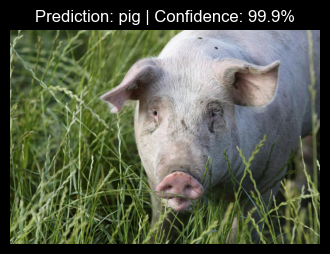

Testing Tricky Edge-Case Image:


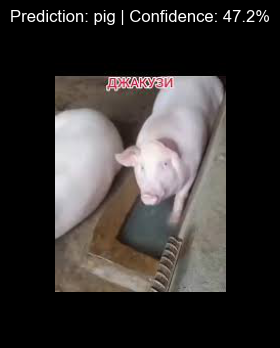

In [31]:
import os

cv_preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def predict_local_image(image_path, model, classes):
    """
    Loads a local image, applies transformations,
    and returns the model's prediction and confidence score.
    """
    if not os.path.exists(image_path):
        print(f"File not found: {image_path}")
        return

    try:
        img = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"Failed to open image: {e}")
        return

    img_tensor = cv_preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        confidence, preds = torch.max(probabilities, 0)

    predicted_class = classes[preds.item()]

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class} | Confidence: {confidence.item():.1%}")
    plt.show()

image_normal = "data/test_images/normal_pig.jpg"
image_tricky = "data/test_images/bad_qual_pig.jpeg"

print("Testing Normal Image:")
predict_local_image(image_normal, cv_model, cv_classes)
print("Testing Tricky Edge-Case Image:")
predict_local_image(image_tricky, cv_model, cv_classes)